Escenario 2 IA TRABAJO 
datos sin etiquetar que hacemos ?!!

pasamos de Machine Learning Supervisado a Machine Learning No Supervisado (Unsupervised ML For Predictive Maintenance).

En esta etapa el enfoque cambia por completo. Ya no vamos a usar las etiquetas (Machine failure o Failure Type) para entrenar los modelos. El objetivo ahora es dejar que los algoritmos analicen las características físicas de las máquinas (Xfeatures) por sí mismos para descubrir patrones ocultos, agrupar datos similares o encontrar anomalías.

De acuerdo con el temario de tu profesor, los temas clave son:

Clustering (Agrupamiento): Usando KMeans y DBSCAN.

Reducción de Dimensionalidad: Usando PCA (Análisis de Componentes Principales).

Anomaly Detection (Detección de Anomalías): Identificar lecturas de sensores que se desvían de los valores estándar.

Paso 1: Preparación de Datos para Aprendizaje No Supervisado
Antes de aplicar cualquier algoritmo de Clustering como KMeans, hay una regla de oro: Los datos DEBEN estar escalados. Como KMeans calcula distancias matemáticas (euclidianas) entre los puntos, si no usamos los datos escalados, las RPM (que están en miles) dominarán por completo el algoritmo, ignorando al Torque y a las Temperaturas.

In [1]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
df = pd. read_csv("C:/Users/Cristina/Documents/E1/ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
#revisar si faltan datos 
# Acceder a la columna por nombre

# Conteo de valores nulos en toda la tabla
df.shape

(10000, 14)

In [4]:
# descripcion 
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

##### hagamosun recuento de oraciones solo para ver los datos que tenemos 

In [6]:
#columnas de relleno 
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve exactamente el nombre de la falla
    return "No Failure"  # usa la misma etiqueta que el dataset original

df["Failure Type"] = df.apply(classify_failure_type, axis=1)


<Axes: xlabel='Failure Type', ylabel='count'>

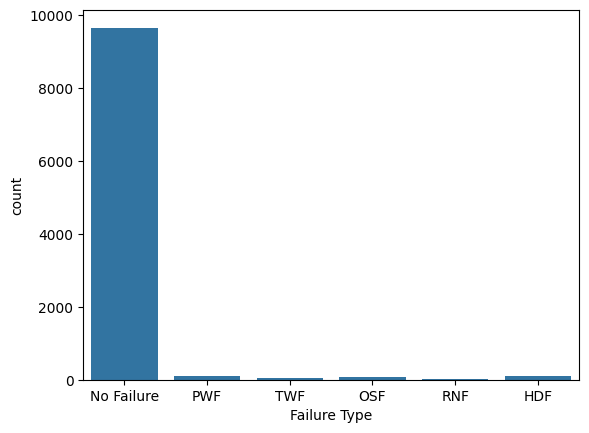

In [8]:
sns.countplot(x="Failure Type", data=df)

datos de etiqueta 

<Axes: xlabel='Machine failure', ylabel='count'>

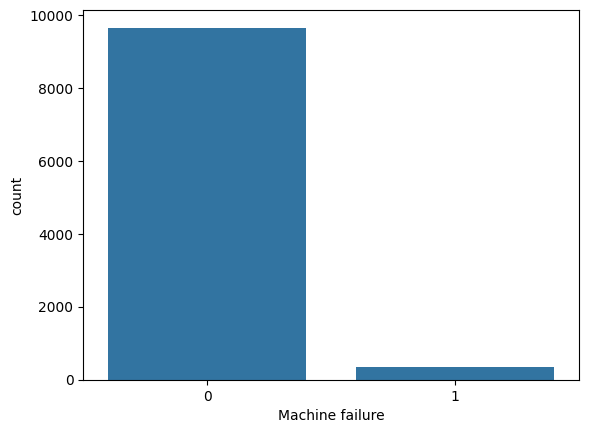

In [11]:
sns.countplot(x="Machine failure", data=df)

#### cuantas clases hay en nuestro conjunto de datos?
 clasificar 
  metodo 1 :Elbow Method (Método del Codo): Que mide la inercia (la distancia interna de los grupos).
  metodo 2 :Silhouette (Coeficiente de Silueta): Que es un método genial porque mide qué tan bien separados están los clusters entre sí y qué tan compactos son por dentro. Da un puntaje entre -1 y 1 (donde más cercano a 1 significa que los grupos están perfectamente definidos).

In [ ]:
## como encontramos cuantos clusteres hay en nuestro conjuntode datos?...

df. columns

seleccionamos datos sensoriales 

In [ ]:
feature_cols